<h2> Visualizations terminal results</h2>

In [6]:
from pathlib import Path
from typing import Any, Dict

import pickle
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def load_pickle_prediction(path: Path) -> Dict[str, Any]:
    """Load a prediction pickle file into memory.

    Parameters
    ----------
    path: Path
        Path to the prediction file.

    Returns
    -------
    Dict[str, Any]
        A dictionary whose keys are metric fields and values are the stored numpy
        arrays.
    """
    obj = []
    with open(path, "rb") as f_in:
        while 1:
            try:
                obj.append(pickle.load(f_in))
            except EOFError:
                break
    return {k: v for x in obj for k, v in x.items()}


<br >

<h3>Training 3: Transcriptions and Augmentations</h3>

In [8]:
root = "results_model_v1/"

In [9]:
output_lev0 = load_pickle_prediction(Path(root + "dummy-stl25le1/e200_train/metric_levenshtein.pkl"))
output_lev0_best = load_pickle_prediction(Path(root + "dummy-stl25le1/best_eval/metric_levenshtein.pkl"))

output_lev1 = load_pickle_prediction(Path(root + "dummy-71spo6mw/e90_train/metric_levenshtein.pkl"))
output_lev1_best = load_pickle_prediction(Path(root + "dummy-71spo6mw/best_eval/metric_levenshtein.pkl"))

output_lev2 = load_pickle_prediction(Path(root + "dummy-2giyfbxj/e200_train/metric_levenshtein.pkl"))
output_lev2_best = load_pickle_prediction(Path(root + "dummy-2giyfbxj/best_eval/metric_levenshtein.pkl"))

output_lev3 = load_pickle_prediction(Path(root + "dummy-ua4bgxid/e200_train/metric_levenshtein.pkl"))
output_lev3_best = load_pickle_prediction(Path(root + "dummy-ua4bgxid/best_eval/metric_levenshtein.pkl"))

output_lev4 = load_pickle_prediction(Path(root + "dummy-0cmoqj5k/e200_train/metric_levenshtein.pkl"))
output_lev4_best = load_pickle_prediction(Path(root + "dummy-0cmoqj5k/best_eval/metric_levenshtein.pkl"))

output_lev5 = load_pickle_prediction(Path(root + "dummy-gaoyaidz/e200_train/metric_levenshtein.pkl"))
output_lev5_best = load_pickle_prediction(Path(root + "dummy-gaoyaidz/best_eval/metric_levenshtein.pkl"))

output_lev6 = load_pickle_prediction(Path(root + "dummy-q1c2g7tm/e200_train/metric_levenshtein.pkl"))
output_lev6_best = load_pickle_prediction(Path(root + "dummy-q1c2g7tm/best_eval/metric_levenshtein.pkl"))

output_lev7 = load_pickle_prediction(Path(root + "dummy-3r1a0ff5/e200_train/metric_levenshtein.pkl"))
output_lev7_best = load_pickle_prediction(Path(root + "dummy-3r1a0ff5/best_eval/metric_levenshtein.pkl"))

output_lev8 = load_pickle_prediction(Path(root + "dummy-0indazlc/e200_train/metric_levenshtein.pkl"))
output_lev8_best = load_pickle_prediction(Path(root + "dummy-0indazlc/best_eval/metric_levenshtein.pkl"))

output_lev9 = load_pickle_prediction(Path(root + "dummy-ph7ybv4l/e500_train/metric_levenshtein.pkl"))
output_lev9_best = load_pickle_prediction(Path(root + "dummy-ph7ybv4l/best_eval/metric_levenshtein.pkl"))

<h4>Last epochs</h4>

In [10]:
x0 = list(output_lev0_best.keys())
y0 = [y * 100 for y in list(output_lev0_best.values())]

x1 = list(output_lev1_best.keys())
y1 = [y * 100 for y in list(output_lev1_best.values())]

x2 = list(output_lev2_best.keys())
y2 = [y * 100 for y in list(output_lev2_best.values())]

x3 = list(output_lev3_best.keys())
y3 = [y * 100 for y in list(output_lev3_best.values())]

x4 = list(output_lev4_best.keys())
y4 = [y * 100 for y in list(output_lev4_best.values())]

x5 = list(output_lev5_best.keys())
y5 = [y * 100 for y in list(output_lev5_best.values())]

x6 = list(output_lev6_best.keys())
y6 = [y * 100 for y in list(output_lev6_best.values())]

x7 = list(output_lev7_best.keys())
y7 = [y * 100 for y in list(output_lev7_best.values())]

x8 = list(output_lev8_best.keys())
y8 = [y * 100 for y in list(output_lev8_best.values())]

x9 = list(output_lev9_best.keys())
y9 = [y * 100 for y in list(output_lev9_best.values())]


xs = [x0, x1, x2, x3, x4, x5, x6, x7, x8, x9]
ys = [y0, y1, y2, y3, y4, y5, y6, y7, y8, y9]

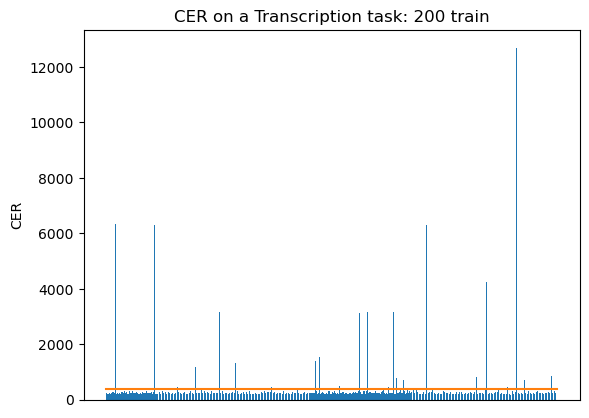

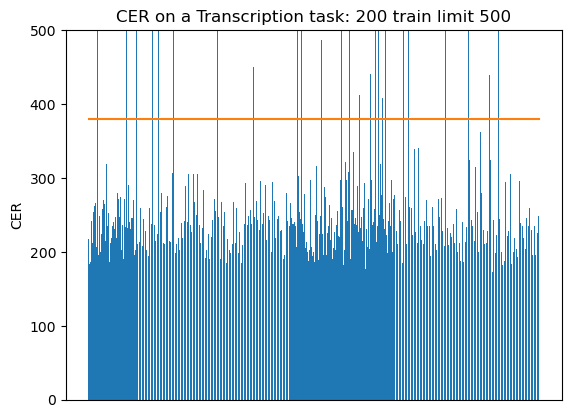

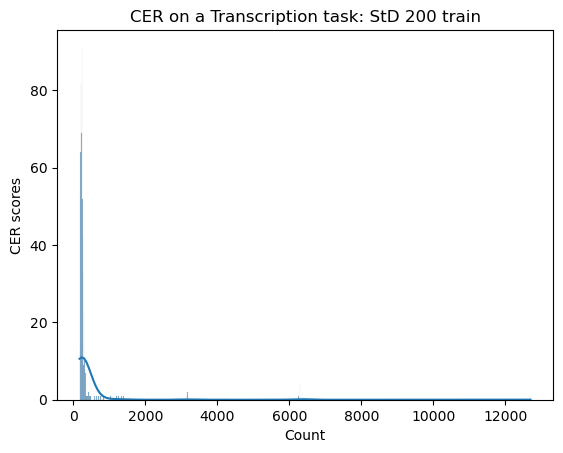

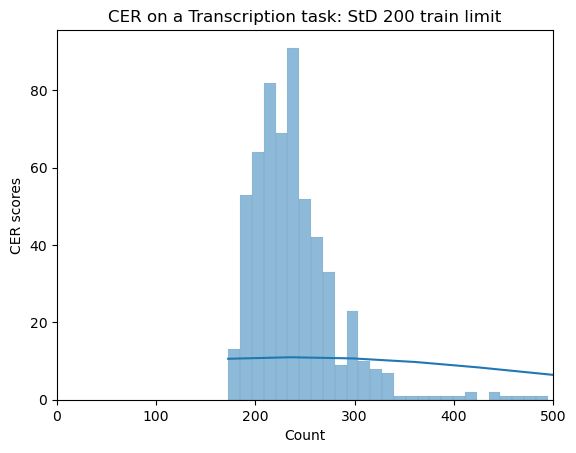

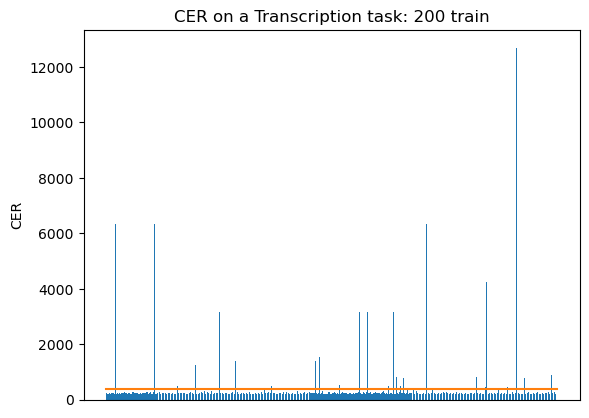

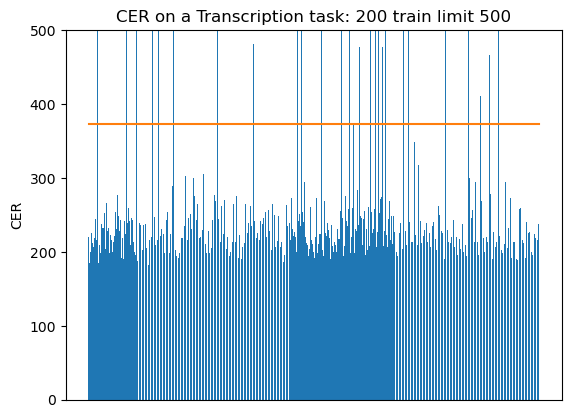

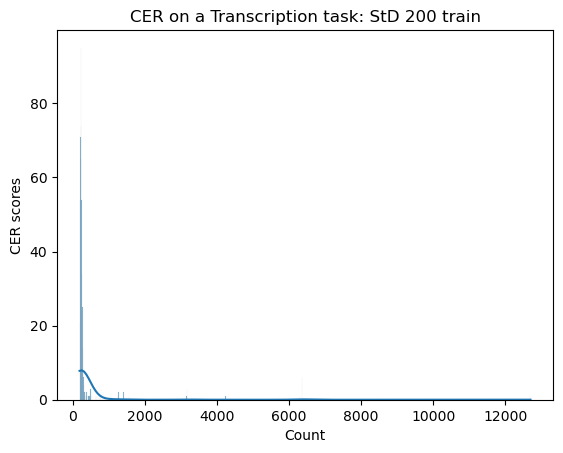

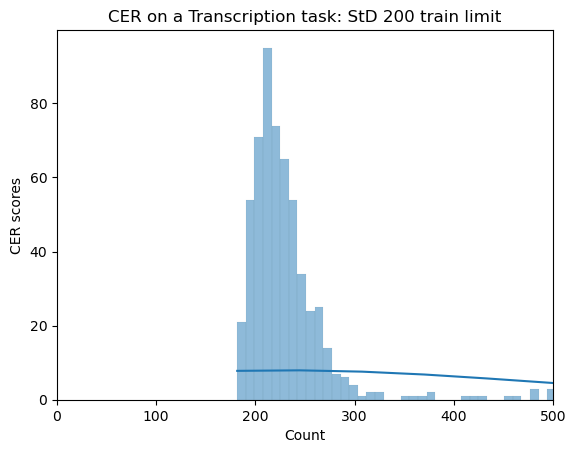

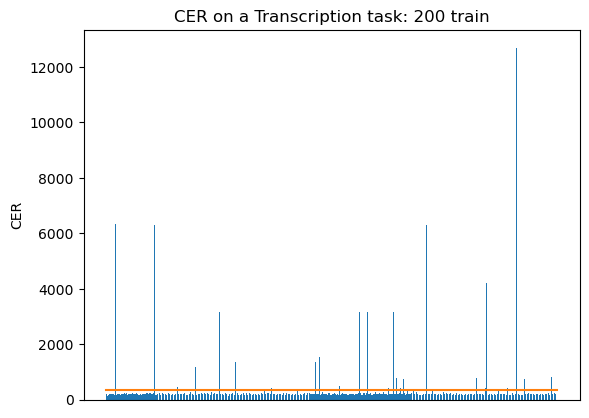

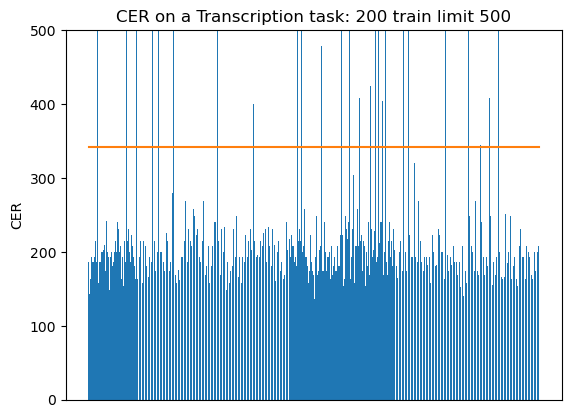

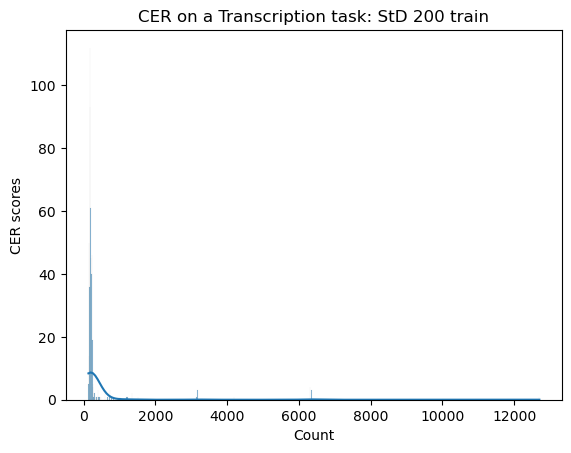

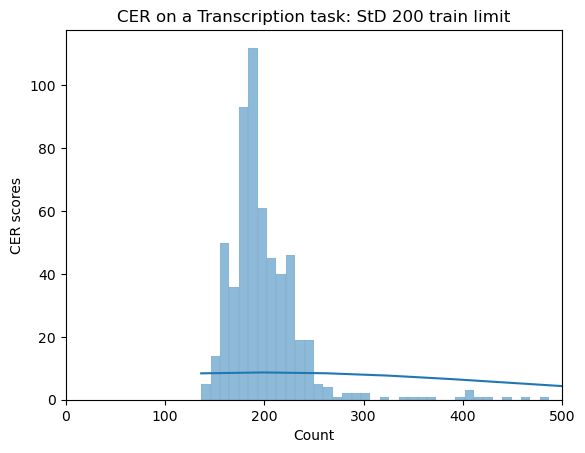

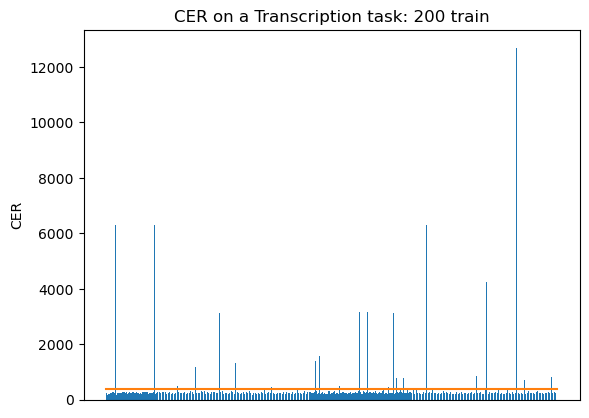

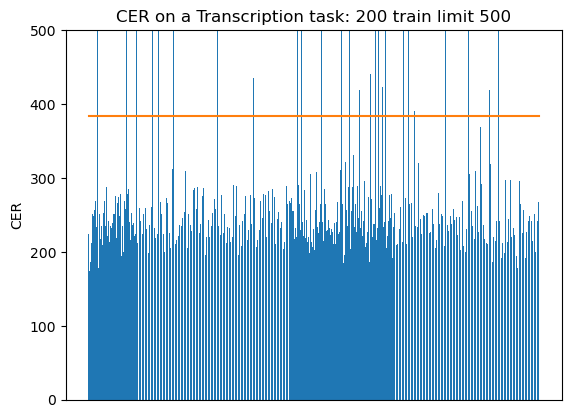

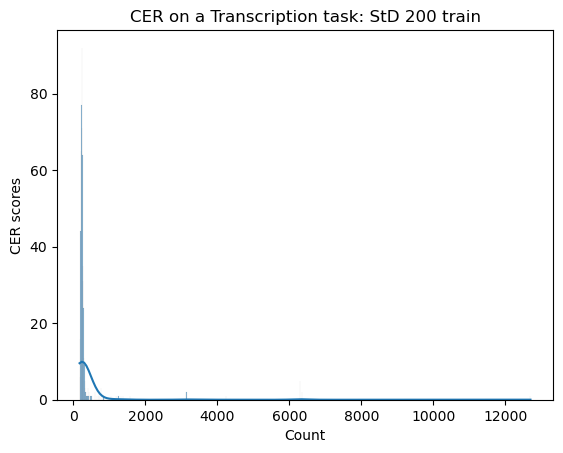

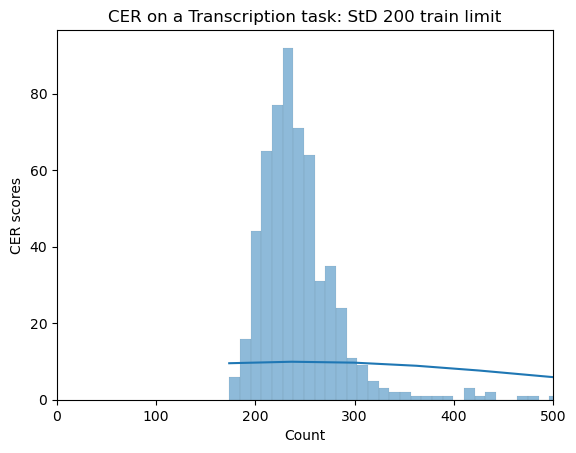

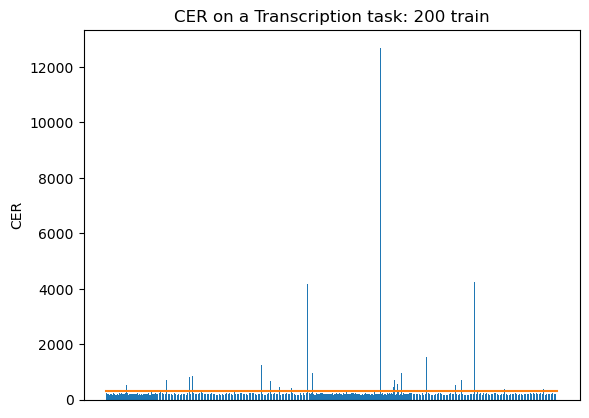

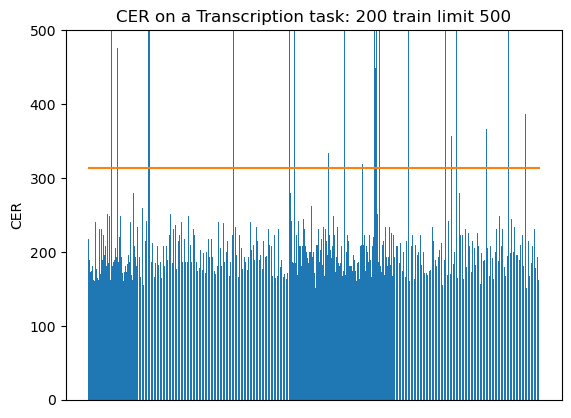

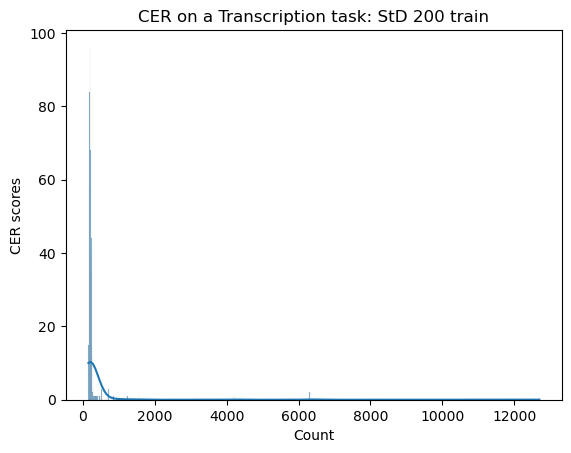

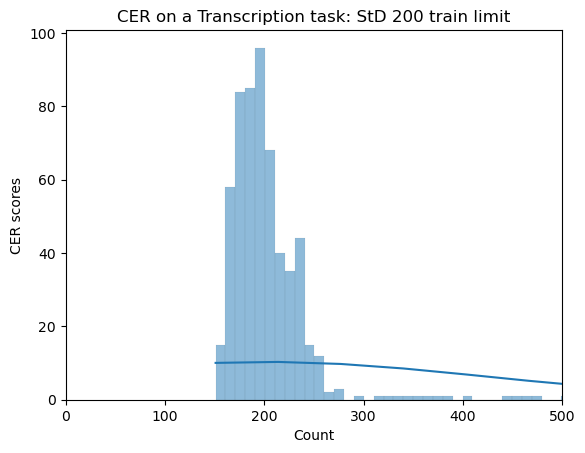

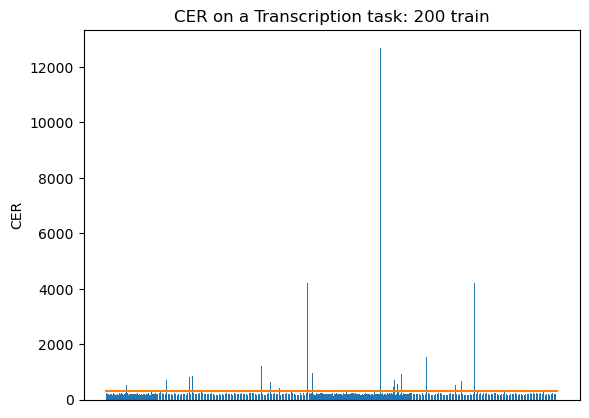

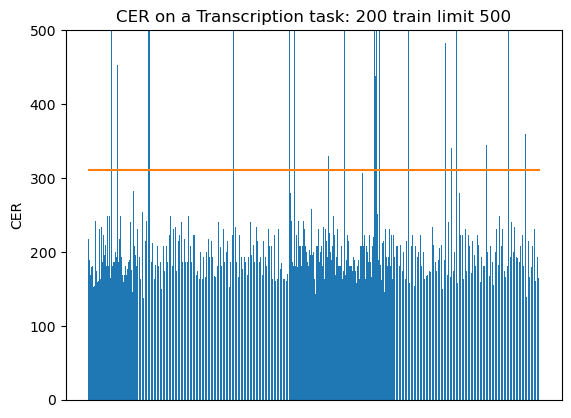

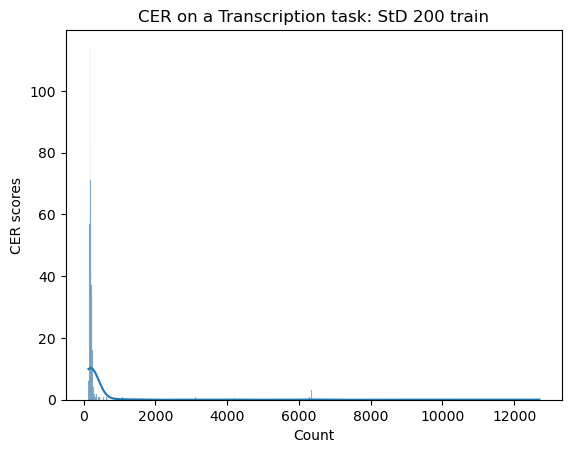

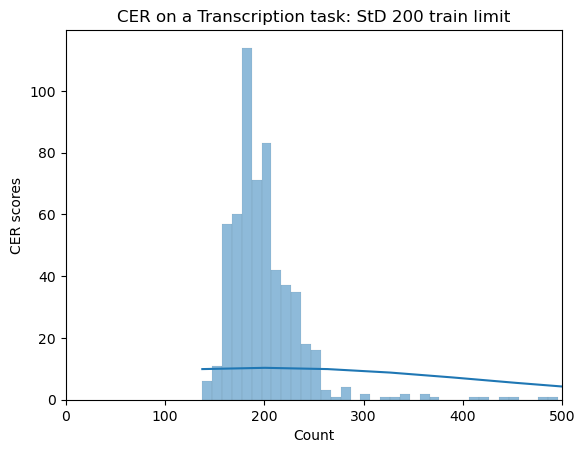

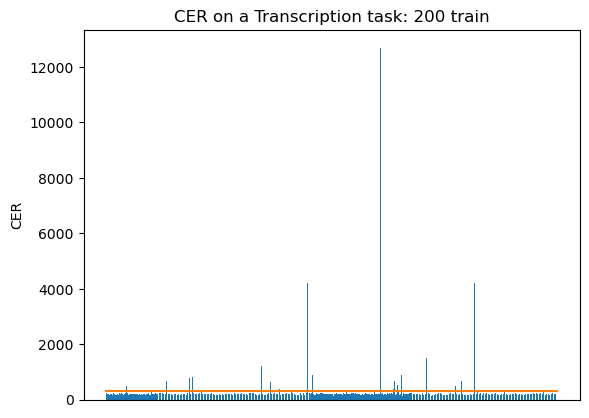

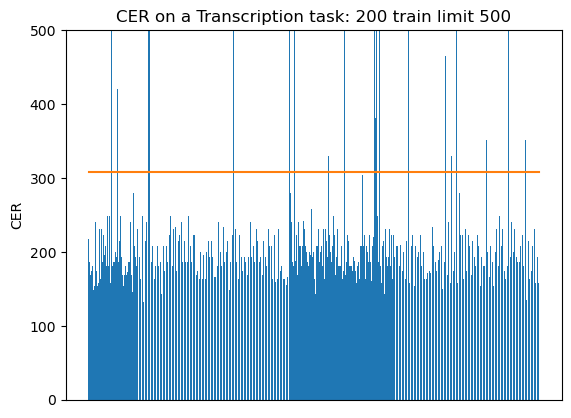

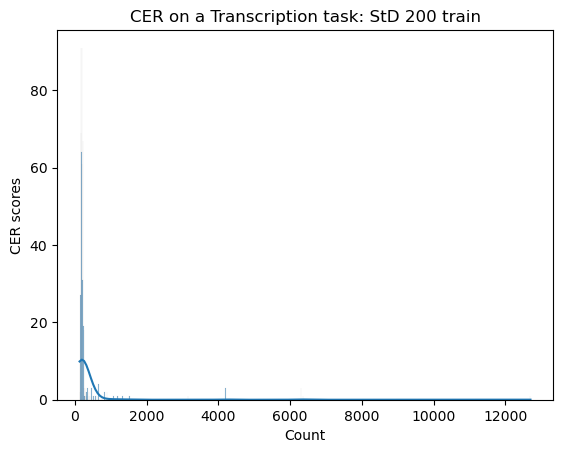

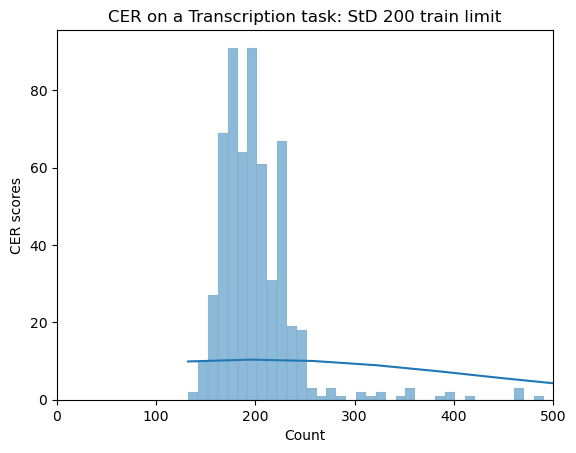

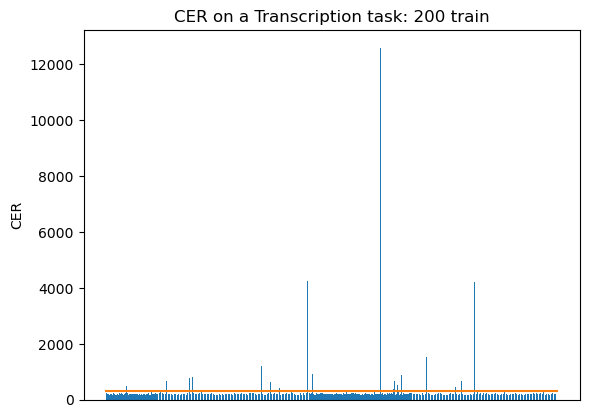

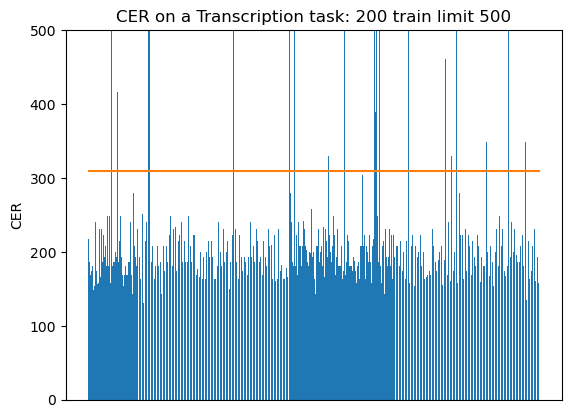

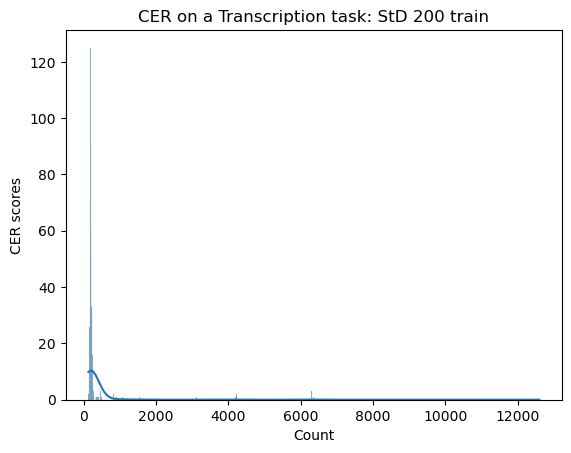

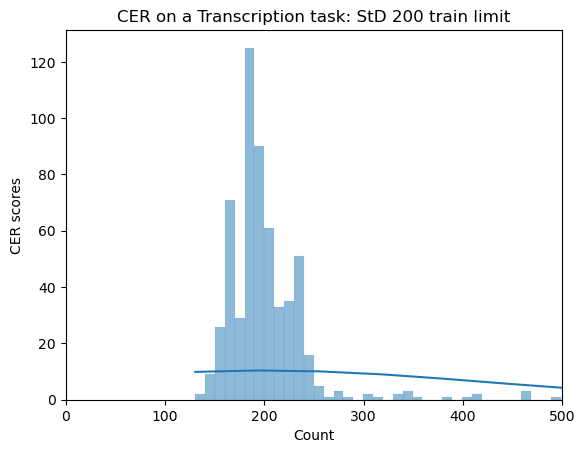

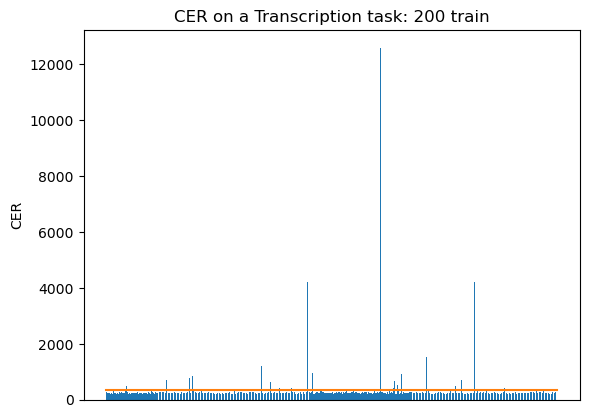

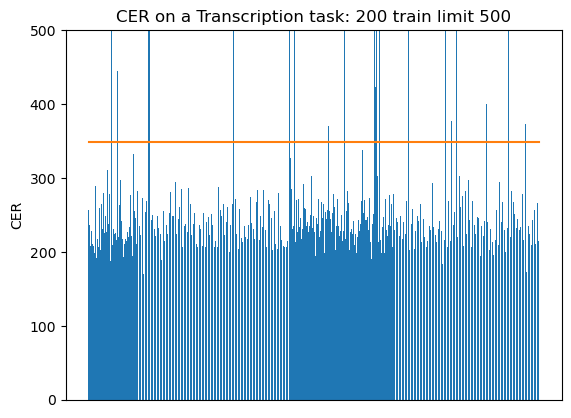

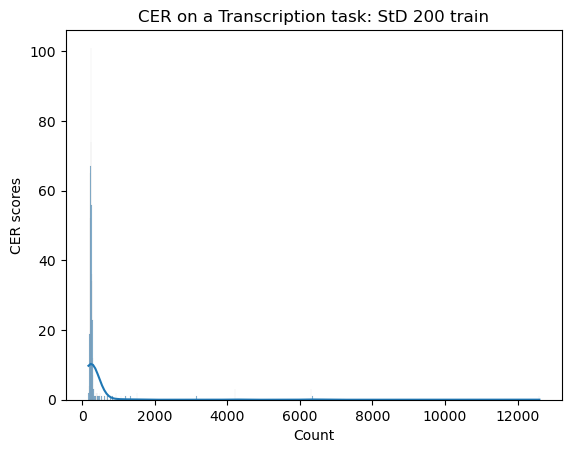

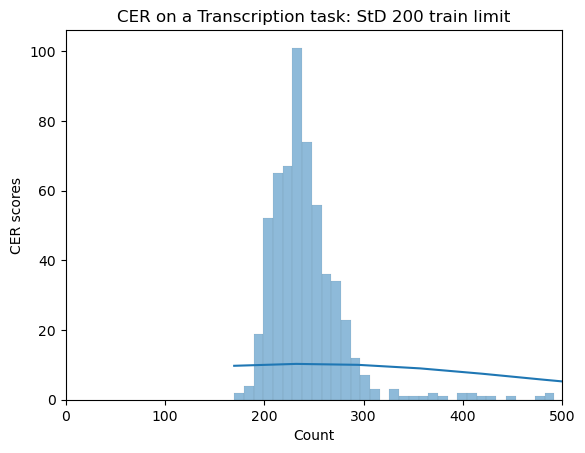

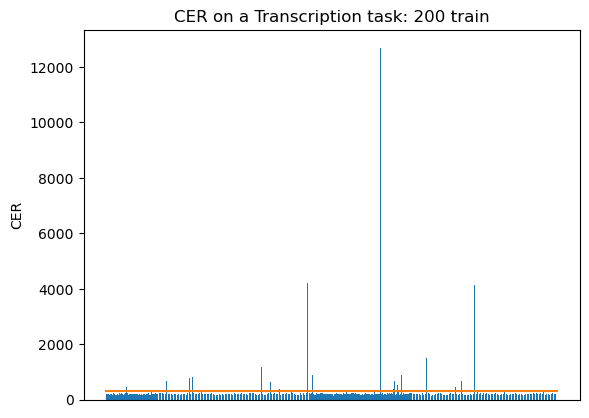

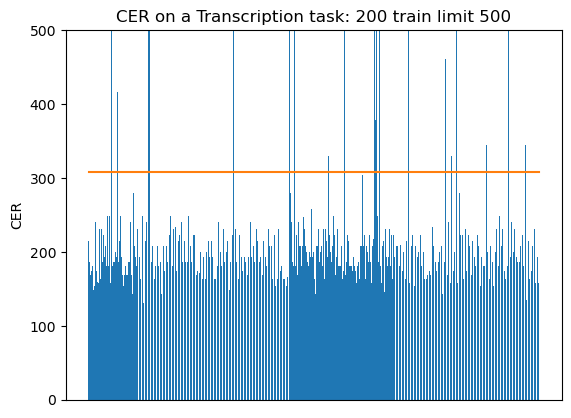

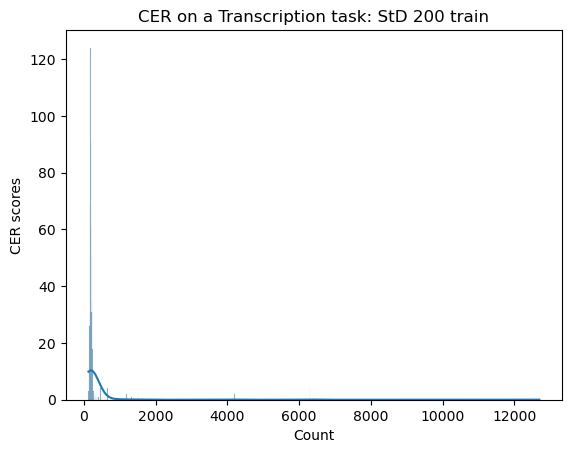

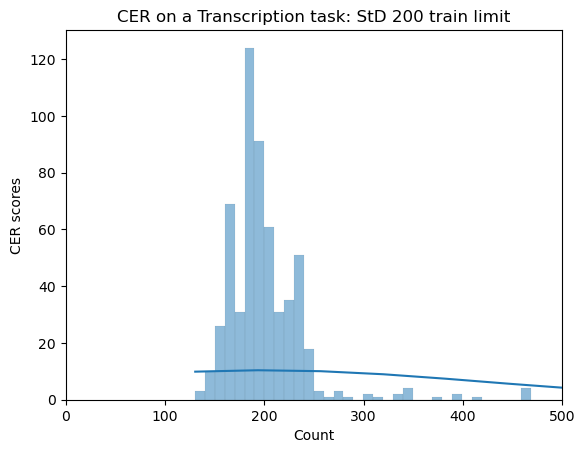

In [11]:
i = 0

for x, y in zip(xs, ys):
    
    # Mean CharactER
    plt.bar(x, y)
    plt.plot(x, [np.mean(y)]*len(x), color="tab:orange")

    plt.xlabel("Images")
    plt.ylabel("CER")
    plt.title("CER on a Transcription task: 200 train")

    plt.gca().axes.get_xaxis().set_visible(False)
    plt.ylim(0)

    plt.savefig('plots/pkl/tr_02_lev' + str(i) + '_mean.png', bbox_inches='tight')
    plt.show()
    
    # Mean CharactER limit 500
    plt.bar(x, y)
    plt.plot(x, [np.mean(y)]*len(x), color="tab:orange")

    plt.xlabel("Images")
    plt.ylabel("CER")
    plt.title("CER on a Transcription task: 200 train limit 500")

    plt.gca().axes.get_xaxis().set_visible(False)
    plt.ylim(0, 500)

    plt.savefig('plots/pkl/tr_02_lev' + str(i) + '_mean_500.png', bbox_inches='tight')
    plt.show()
    
    # Std CharactER
    sns.histplot(data=y, kde = True) 

    plt.xlabel("Count")
    plt.ylabel("CER scores")
    plt.title("CER on a Transcription task: StD 200 train")

    plt.savefig('plots/pkl/tr_02_lev' + str(i) + '_std.png', bbox_inches='tight')
    plt.show()
    
    # Std CharactER limit 500
    sns.histplot(data=y, kde = True) 

    plt.xlabel("Count")
    plt.ylabel("CER scores")
    plt.title("CER on a Transcription task: StD 200 train limit")

    plt.xlim(0, 500)

    plt.savefig('plots/pkl/tr_02_lev' + str(i) + '_std_500.png', bbox_inches='tight')
    plt.show()
    
    i += 1

<h4>Best evaluations</h4>

In [12]:
x0 = list(output_lev0_best.keys())
y0 = [y * 100 for y in list(output_lev0_best.values())]

x1 = list(output_lev1_best.keys())
y1 = [y * 100 for y in list(output_lev1_best.values())]

x2 = list(output_lev2_best.keys())
y2 = [y * 100 for y in list(output_lev2_best.values())]

x3 = list(output_lev3_best.keys())
y3 = [y * 100 for y in list(output_lev3_best.values())]

x4 = list(output_lev4_best.keys())
y4 = [y * 100 for y in list(output_lev4_best.values())]

x5 = list(output_lev5_best.keys())
y5 = [y * 100 for y in list(output_lev5_best.values())]

x6 = list(output_lev6_best.keys())
y6 = [y * 100 for y in list(output_lev6_best.values())]

x7 = list(output_lev7_best.keys())
y7 = [y * 100 for y in list(output_lev7_best.values())]

x8 = list(output_lev8_best.keys())
y8 = [y * 100 for y in list(output_lev8_best.values())]

x9 = list(output_lev9_best.keys())
y9 = [y * 100 for y in list(output_lev9_best.values())]


xs = [x0, x1, x2, x3, x4, x5, x6, x7, x8, x9]
ys = [y0, y1, y2, y3, y4, y5, y6, y7, y8, y9]

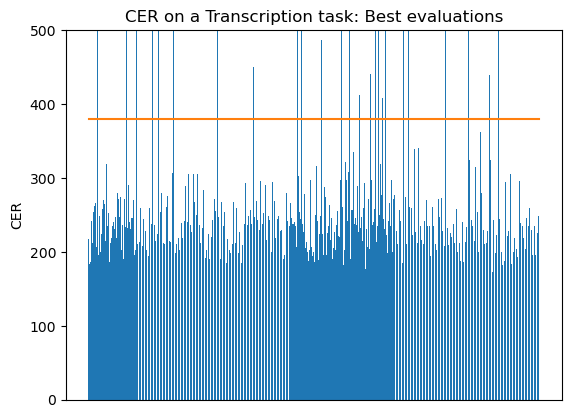

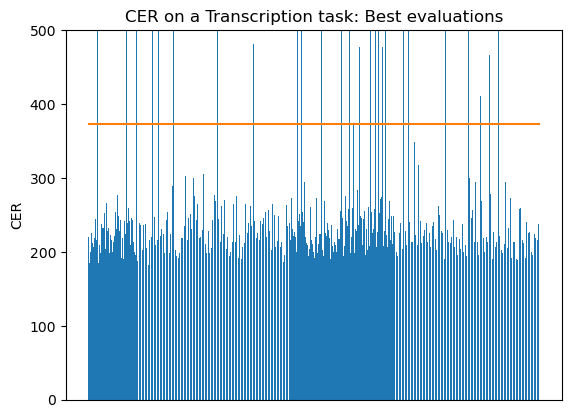

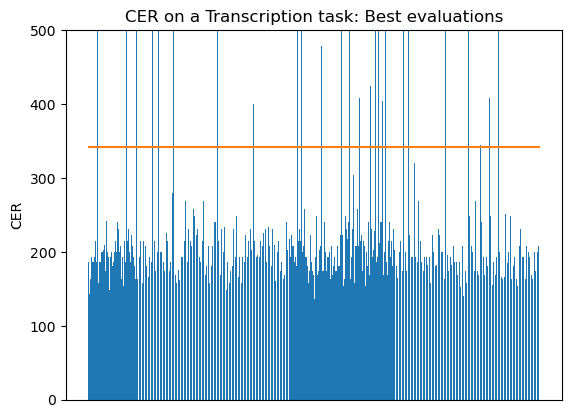

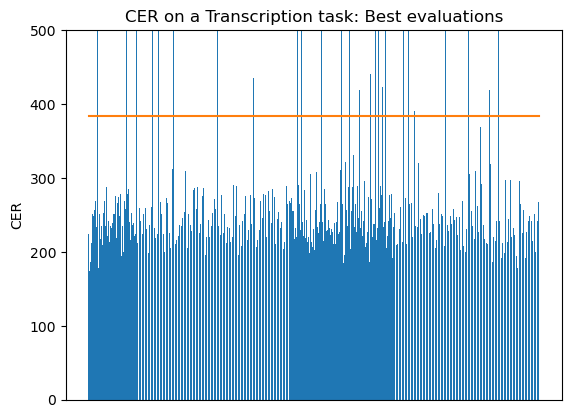

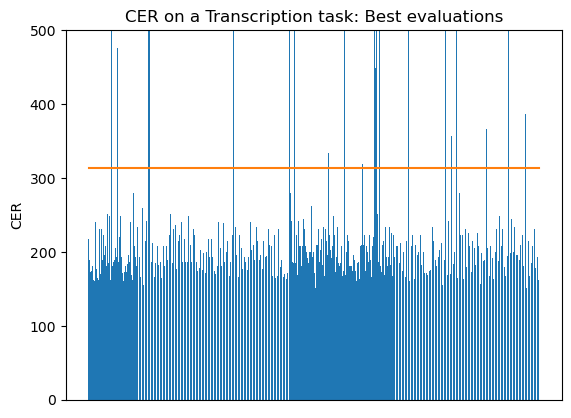

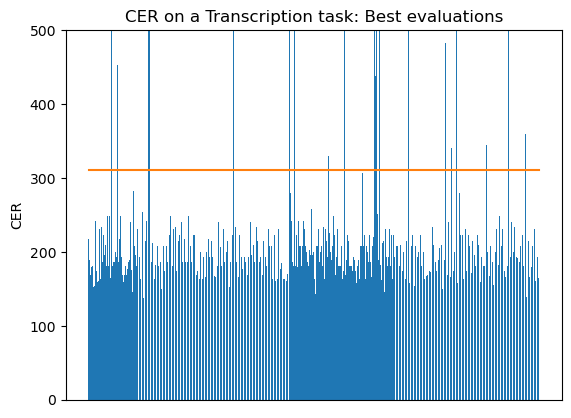

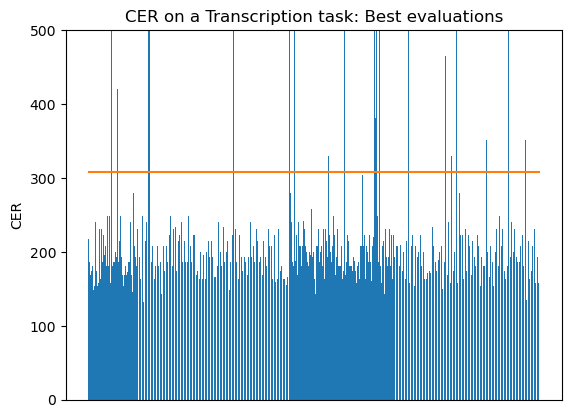

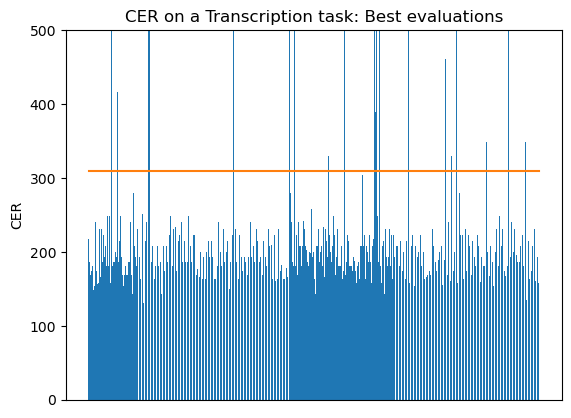

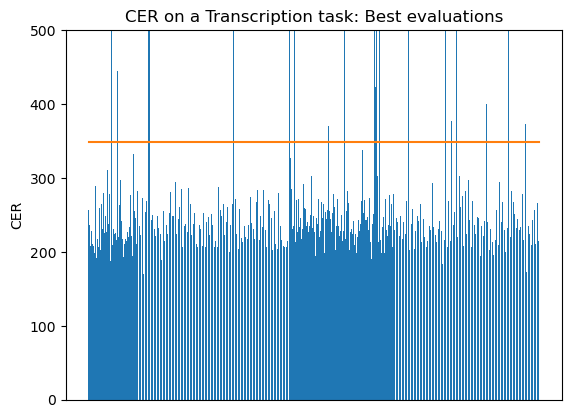

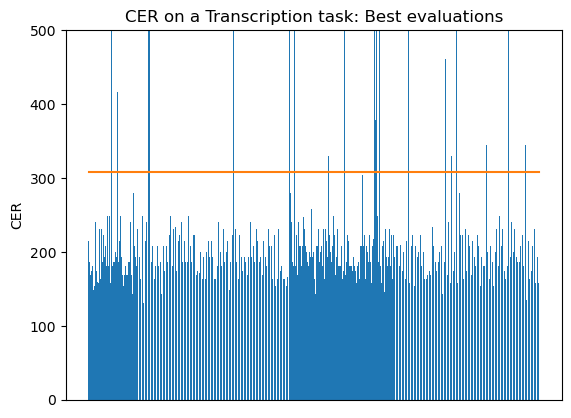

In [13]:
i = 0

for x, y in zip(xs, ys):
    
    plt.bar(x, y)
    plt.plot(x, [np.mean(y)]*len(x), color="tab:orange")

    plt.xlabel("Images")
    plt.ylabel("CER")
    plt.title("CER on a Transcription task: Best evaluations")

    plt.gca().axes.get_xaxis().set_visible(False)
    plt.ylim(0, 500)

    plt.savefig('plots/pkl/tr_02_lev' + str(i) + '_best.png', bbox_inches='tight')
    plt.show()
    
    i += 1

<br >